# 1.参数配置与数据读取

In [2]:
import pandas as pd
import numpy as np

INPUT_FILE = "features_with_proxy.parquet"
OUTPUT_FILE = "features_with_riskindex.parquet"

# 权重向量 W，顺序对应："event_count", "radiance", "dist_to_peak"
W = np.array([0.6019, 0.2276, 0.1705])  # 运行时可修改实际权重，确保和为1

# 特征列名列表（顺序必须与权重对应）
FEATURES = ["event_count", "radiance", "dist_to_peak"]

# 风险等级标签
RISK_LEVELS = ["低风险", "中风险", "高风险"]

df = pd.read_parquet(INPUT_FILE)
print(f"原始数据形状: {df.shape}")

原始数据形状: (2061226, 14)


## 快速统计检验

In [3]:
from scipy import stats

for col in FEATURES:
    data = df[col].dropna()
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)  # Fisher定义，正态为0
    print(f"{col}: 偏度={skew:.10f}, 峰度={kurt:.10f}")

event_count: 偏度=3.0911138058, 峰度=14.6723613739
radiance: 偏度=9.6431617737, 峰度=162.4176025391
dist_to_peak: 偏度=-0.1312747122, 峰度=-1.1458694846


# 2.计算各特征的分位数

In [4]:
# 特征列顺序必须与权重 W 一致
feat_cols = ["event_count", "radiance", "dist_to_peak"]
X = df[feat_cols].to_numpy().astype(float)   # shape (N, 4)

# 对每个特征分别计算 p10, p30, p70, p90
quantiles = {}
for feat in FEATURES:
    quantiles[feat] = {
        "p10": df[feat].quantile(0.10),
        "p30": df[feat].quantile(0.30),
        "p40": df[feat].quantile(0.40),
        "p50": df[feat].quantile(0.50),
        "p70": df[feat].quantile(0.70),
        "p80": df[feat].quantile(0.80),
        "p90": df[feat].quantile(0.90),
        "p95": df[feat].quantile(0.95),
        "p97": df[feat].quantile(0.97),
        "p98": df[feat].quantile(0.98),
        "p99": df[feat].quantile(0.99),
        "p99.5": df[feat].quantile(0.995),
        "p99.9": df[feat].quantile(0.999),
        "p99.95": df[feat].quantile(0.9995),
        "p99.99": df[feat].quantile(0.9999),
        "p99.999": df[feat].quantile(0.99999),
        "p100": df[feat].quantile(1),
    }

print("各特征分位数计算完成：")
for feat, q in quantiles.items():
    print(f"  {feat}: p10={q['p10']:.4f}, p30={q['p30']:.4f}, p40={q['p40']:.4f}, p50={q['p50']:.4f},p70={q['p70']:.4f}, p80={q['p80']:.4f},p90={q['p90']:.4f}, p95={q['p95']:.4f}, p97={q['p97']:.4f}, p98={q['p98']:.4f}, p99={q['p99']:.4f}, p99.5={q['p99.5']:.4f}, p99.9={q['p99.9']:.4f},"
          f"p99.95={q['p99.95']:.4f}, p99.99={q['p99.99']:.4f}, p99.999={q['p99.999']:.4f}, p100={q['p100']:.4f}")

各特征分位数计算完成：
  event_count: p10=1.0000, p30=1.0000, p40=2.0000, p50=2.0000,p70=3.0000, p80=5.0000,p90=8.0000, p95=12.0000, p97=13.0000, p98=13.0000, p99=14.0000, p99.5=21.0000, p99.9=33.0000,p99.95=34.0000, p99.99=34.0000, p99.999=46.0000, p100=49.0000
  radiance: p10=9.9793, p30=19.4523, p40=26.7492, p50=36.3948,p70=87.2064, p80=165.9799,p90=418.2904, p95=705.5313, p97=1054.1466, p98=1412.3418, p99=2431.8389, p99.5=3524.0345, p99.9=5607.2078,p99.95=7034.4029, p99.99=12609.9538, p99.999=16845.0316, p100=19322.8496
  dist_to_peak: p10=0.7100, p30=2.0367, p40=2.6800, p50=3.2867,p70=4.4467, p80=5.0033,p90=5.4933, p95=5.7467, p97=5.9633, p98=6.0733, p99=6.1800, p99.5=6.2300, p99.9=6.2733,p99.95=6.2800, p99.99=6.2800, p99.999=6.2800, p100=6.2800


# 3.定义隶属度函数

In [5]:
def get_membership_array(feat_name, x):
    """x: 形状 (N,) 的该特征值数组，返回 (N, 3) 隶属度数组 [low, mid, high]"""
    q = quantiles[feat_name]
    p10, p30, p40, p50, p70, p90, p95, p97, p98, p99, p995, p999, p9995, p9999, p99999  = q['p10'], q['p30'], q['p40'],q['p50'], q['p70'], q['p90'], q['p95'], q['p97'], q['p98'], q['p99'], q['p99.5'], q['p99.9'], q['p99.95'], q['p99.99'], q['p99.999']

    if feat_name == "dist_to_peak":
        # 低风险（距离远）—— 原高风险公式
        low_condlist = [x >= p90, x > p70, True]
        low_choicelist = [1.0, (x - p70) / (p90 - p70), 0.0]
        low = np.select(low_condlist, low_choicelist)

        # 高风险（距离近）—— 原低风险公式
        high_condlist = [x <= p10, x < p50, True]
        high_choicelist = [1.0, (p50 - x) / (p50 - p10), 0.0]
        high = np.select(high_condlist, high_choicelist)

        # 中风险（不变）
        mid_condlist = [
            (x <= p30) | (x >= p90),
            (x > p30) & (x < p50),
            (x >= p50) & (x <= p70),
            (x > p70) & (x < p90)
        ]
        mid_choicelist = [
            0.0,
            (x - p30) / (p50 - p30),
            1.0,
            (p90 - x) / (p90 - p70)
        ]
        mid = np.select(mid_condlist, mid_choicelist, default=0.0)

    elif feat_name == "radiance":
        # 低风险
        low_condlist = [x <= p95, x < p995, True]
        low_choicelist = [1.0, (p95 - x) / (p995 - p95), 0.0]
        low = np.select(low_condlist, low_choicelist)

        # 高风险
        high_condlist = [x >= p99999, x > p999, True]
        high_choicelist = [1.0, (x - p999) / (p99999 - p999), 0.0]
        high = np.select(high_condlist, high_choicelist)

        # 中风险
        mid_condlist = [
            (x <= p99) | (x >= p9995),
            (x > p99) & (x < p995),
            (x >= p995) & (x <= p999),
            (x > p999) & (x < p9995)
        ]
        mid_choicelist = [
            0.0,
            (x - p99) / (p995 - p99),
            1.0,
            (p9995 - x) / (p9995 - p999)
        ]
        mid = np.select(mid_condlist, mid_choicelist, default=0.0)

    else:
        # 低风险
        low_condlist = [x <= p90, x < p95, True]
        low_choicelist = [1.0, (p95 - x) / (p95 - p90), 0.0]
        low = np.select(low_condlist, low_choicelist)

        # 高风险
        high_condlist = [x >= p9999, x > p99, True]
        high_choicelist = [1.0, (x - p99) / (p9999 - p99), 0.0]
        high = np.select(high_condlist, high_choicelist)

        # 中风险
        mid_condlist = [
            (x <= p90) | (x >= p995),
            (x > p90) & (x < p95),
            (x >= p95) & (x <= p99),
            (x > p99) & (x < p995)
        ]
        mid_choicelist = [
            0.0,
            (x - p90) / (p95 - p90),
            1.0,
            (p999 - x) / (p999 - p995)
        ]
        mid = np.select(mid_condlist, mid_choicelist, default=0.0)

    # 堆叠为 (N, 3)
    return np.stack([low, mid, high], axis=1)

# 4.构建模糊关系矩阵与模糊合成 B = W ∘ R

In [6]:
# 分别计算每个特征的隶属度数组，并沿特征维度堆叠为 (N, 4, 3)
R_list = []
for i, feat in enumerate(feat_cols):
    R_i = get_membership_array(feat, X[:, i])  # (N, 3)
    R_list.append(R_i)
R = np.stack(R_list, axis=1)   # shape: (N, 4, 3)

# 方法1：使用 einsum（推荐，清晰高效）
B = np.einsum('f,nfc->nc', W, R)   # shape (N, 3)

# 方法2：等效广播计算
# B = (W[None, :, None] * R).sum(axis=1)

# 4.确定隶属度与强度

In [7]:
# 1. 计算原始风险指数（加权得分）
# B 形状为 (N, 3)，权重系数：低风险=1，中风险=2，高风险=3
weights_score = np.array([1, 2, 3])
raw_score = B @ weights_score   # (N,)
# raw_score = np.minimum(B)   # (N,)

# 2. 全局 min-max 归一化
score_min = raw_score.min()
score_max = raw_score.max()
norm_score = (raw_score - score_min) / (score_max - score_min)

# 3. 根据归一化得分划分风险等级
risk_level = np.select(
    [norm_score <= 0.4, norm_score <= 0.7],
    ['低风险', '中风险'],
    default='高风险'
)

# 4. 将结果写入 DataFrame
df['raw_risk_score'] = raw_score          # 原始得分（可选）
df['norm_risk_score'] = norm_score        # 归一化得分（可选）
df['risk_level'] = risk_level             # 最终风险等级

# 5. 删除不再需要的风险强度列（如果之前有）
if 'risk_intensity' in df.columns:
    df.drop(columns=['risk_intensity'], inplace=True)

# 5.保存结果

In [8]:
df.to_parquet(OUTPUT_FILE, index=False)
print(f"结果已保存至: {OUTPUT_FILE}")

# 预览前几行结果
print("\n结果预览（前5行）：")
print(df.head())

结果已保存至: features_with_riskindex.parquet

结果预览（前5行）：
      radiance  footprint  event_count  hour  month  day  \
0  2245.567627     1200.0         12.0   1.1      3    1   
1   578.699829      300.0          3.0   1.1      3    1   
2   766.174438      400.0          4.0   1.1      3    1   
3   215.219452      100.0          1.0   1.1      3    1   
4   816.902710      400.0          4.0   1.1      3    1   

   avg_energy_per_event  is_high_radiance  is_large_footprint  is_daytime  \
0            187.130630                 1                   1           0   
1            192.899948                 1                   0           0   
2            191.543610                 1                   0           0   
3            215.219452                 1                   0           0   
4            204.225677                 1                   0           0   

   is_afternoon  dist_to_peak  proxy_risk_pc1  proxy_risk_weighted  \
0             0          3.11        4.624008         

# 分布诊断

In [9]:
# 区间比例诊断
for feat in FEATURES:
    q = quantiles[feat]
    p30, p50, p70, p90 = q['p30'], q['p50'], q['p70'], q['p90']
    col = df[feat]
    print(f"\n{feat}:")
    print(f"  ≤p30 ({p30:.3f}): {(col <= p30).mean():.1%}")
    print(f"  ≤p50 ({p50:.3f}): {(col <= p50).mean():.1%}")
    print(f"  >p70 ({p70:.3f}): {(col > p70).mean():.1%}")
    print(f"  >p90 ({p90:.3f}): {(col > p90).mean():.1%}")


event_count:
  ≤p30 (1.000): 34.3%
  ≤p50 (2.000): 61.2%
  >p70 (3.000): 28.5%
  >p90 (8.000): 8.8%

radiance:
  ≤p30 (19.452): 30.0%
  ≤p50 (36.395): 50.0%
  >p70 (87.206): 30.0%
  >p90 (418.290): 10.0%

dist_to_peak:
  ≤p30 (2.037): 30.1%
  ≤p50 (3.287): 50.1%
  >p70 (4.447): 29.9%
  >p90 (5.493): 10.0%


# 比例统计

风险等级统计

数量统计：
  低风险: 1,952,254 条 (94.71%)
  中风险: 100,498 条 (4.88%)
  高风险: 8,474 条 (0.41%)

总计: 2,061,226 条


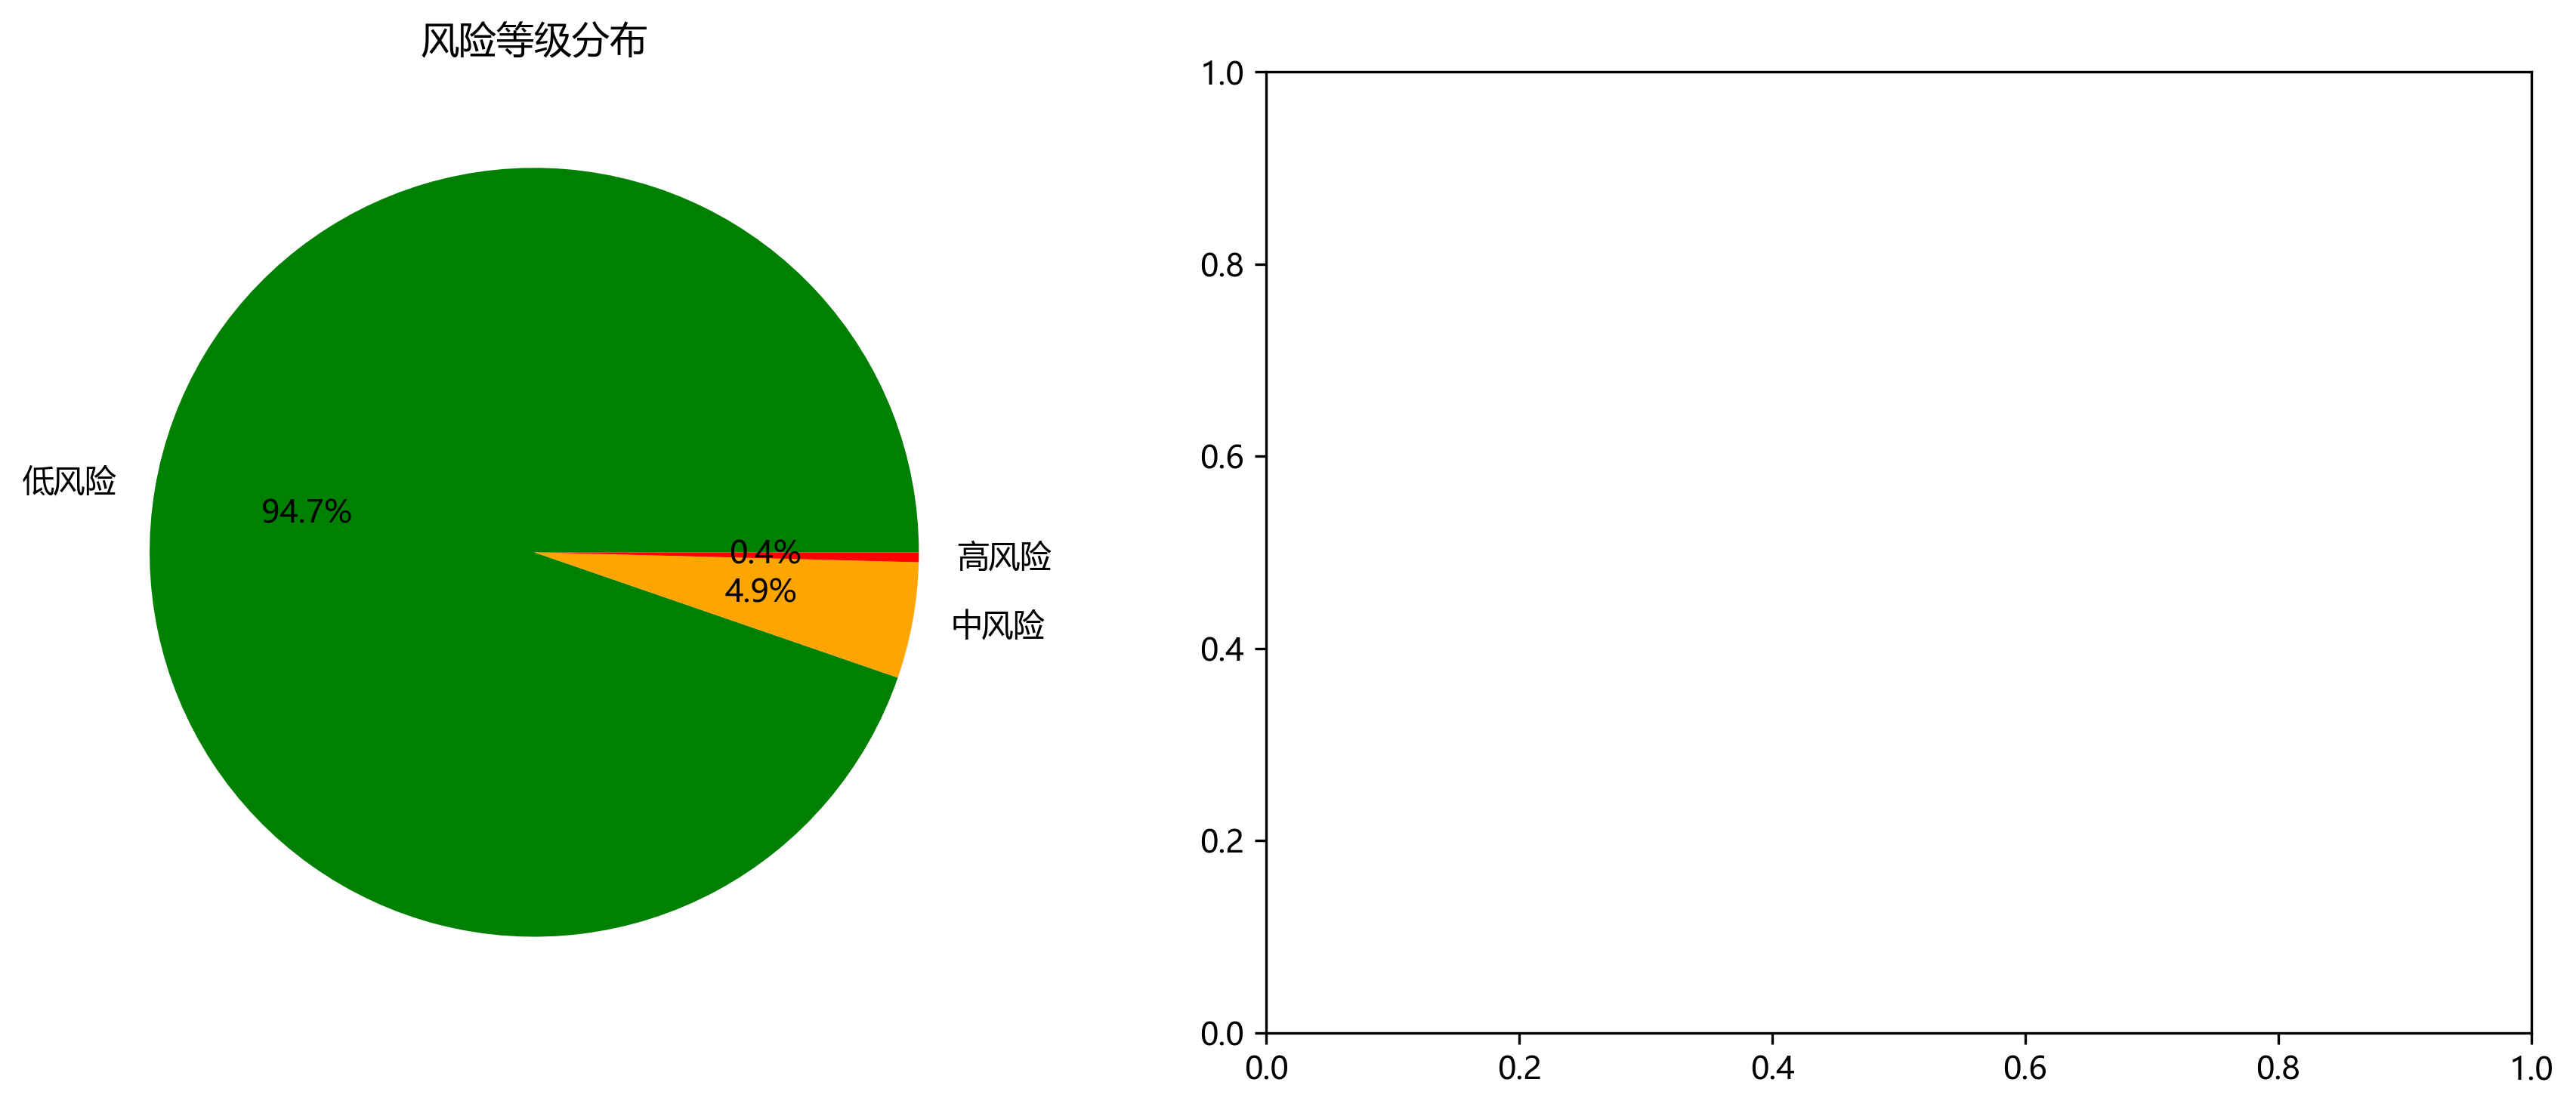

In [10]:
# 统计各风险等级的数量和比例
risk_counts = df['risk_level'].value_counts()
risk_ratio = df['risk_level'].value_counts(normalize=True)

print("=" * 50)
print("风险等级统计")
print("=" * 50)
print(f"\n数量统计：")
for level in ['低风险', '中风险', '高风险']:
    count = risk_counts.get(level, 0)
    ratio = risk_ratio.get(level, 0)
    print(f"  {level}: {count:,} 条 ({ratio:.2%})")

print(f"\n总计: {len(df):,} 条")

# 可视化（可选）
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 饼图
axes[0].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
            colors=['green', 'orange', 'red'])
axes[0].set_title('风险等级分布')

plt.tight_layout()
plt.show()

# 得分区间统计

归一化风险得分分段统计
区间                  样本数         比例
----------------------------------------
[0.0, 0.1)       18,141     0.88%
[0.1, 0.2)      645,917    31.34%
[0.2, 0.3)    1,249,176    60.60%
[0.3, 0.4)       39,020     1.89%
[0.4, 0.5)       75,602     3.67%
[0.5, 0.6)       19,725     0.96%
[0.6, 0.7)        5,171     0.25%
[0.7, 0.8)        6,665     0.32%
[0.8, 0.9)        1,720     0.08%
[0.9, 1.0]           89     0.00%
----------------------------------------
总计            2,061,226    100.00%


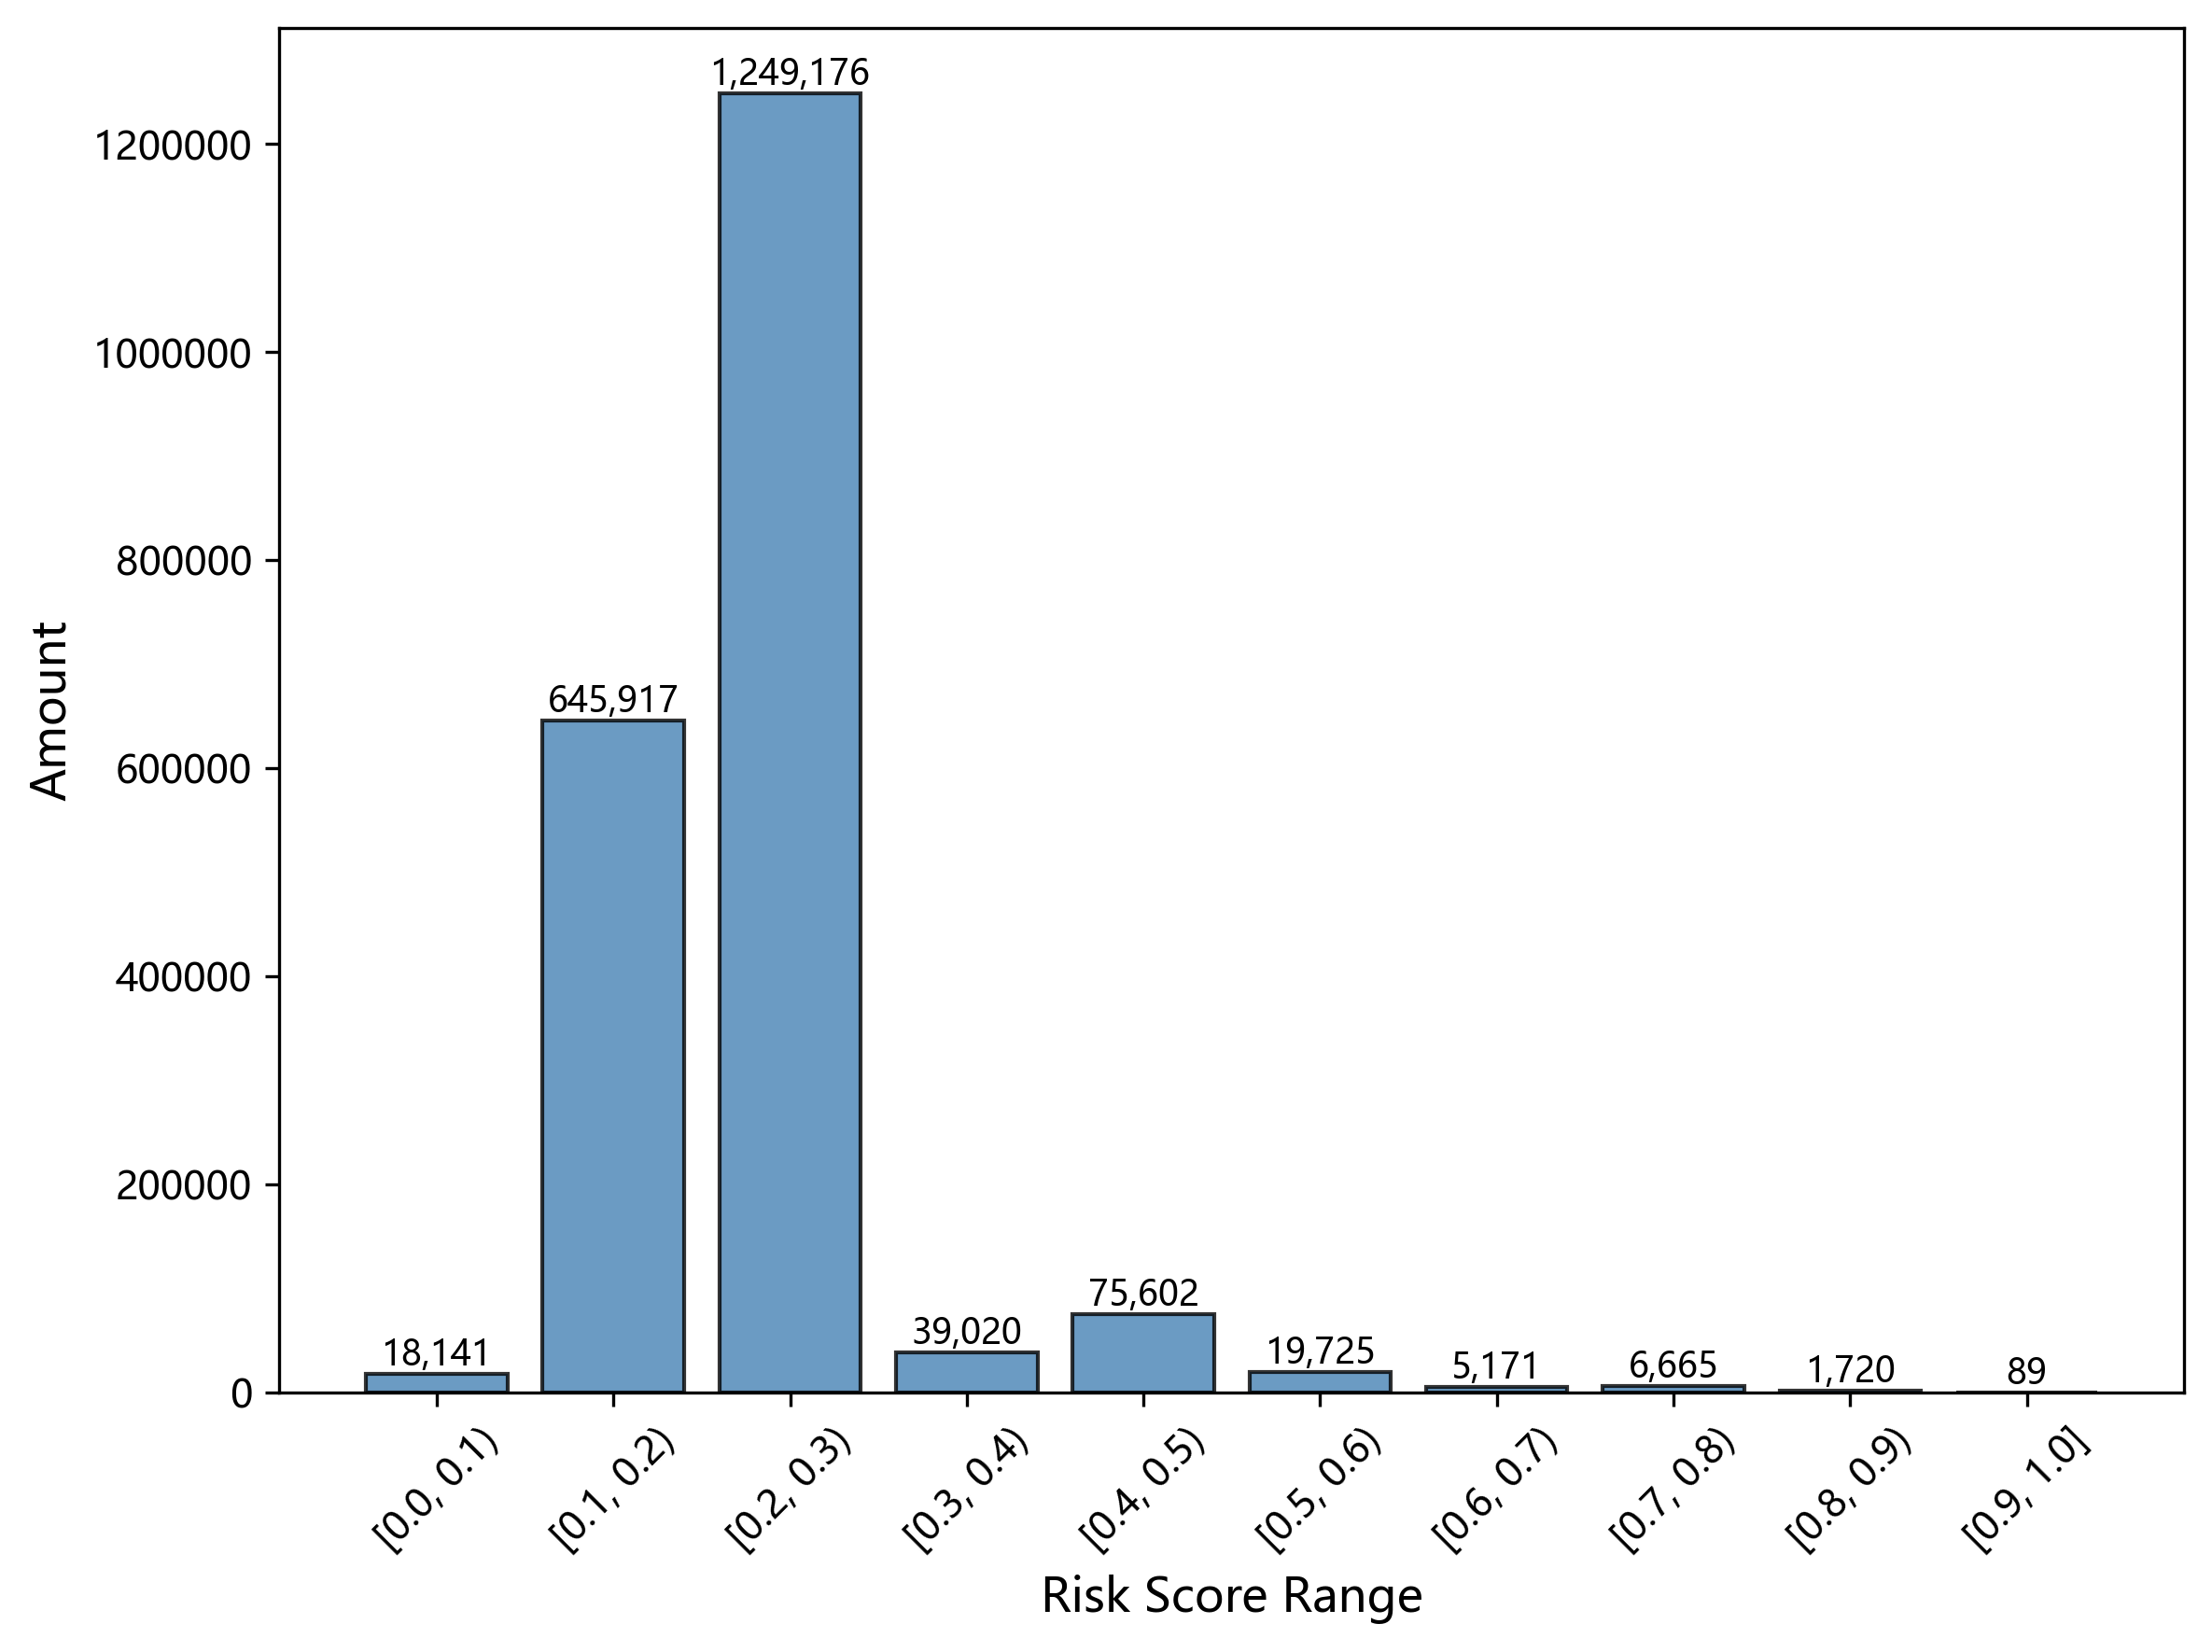

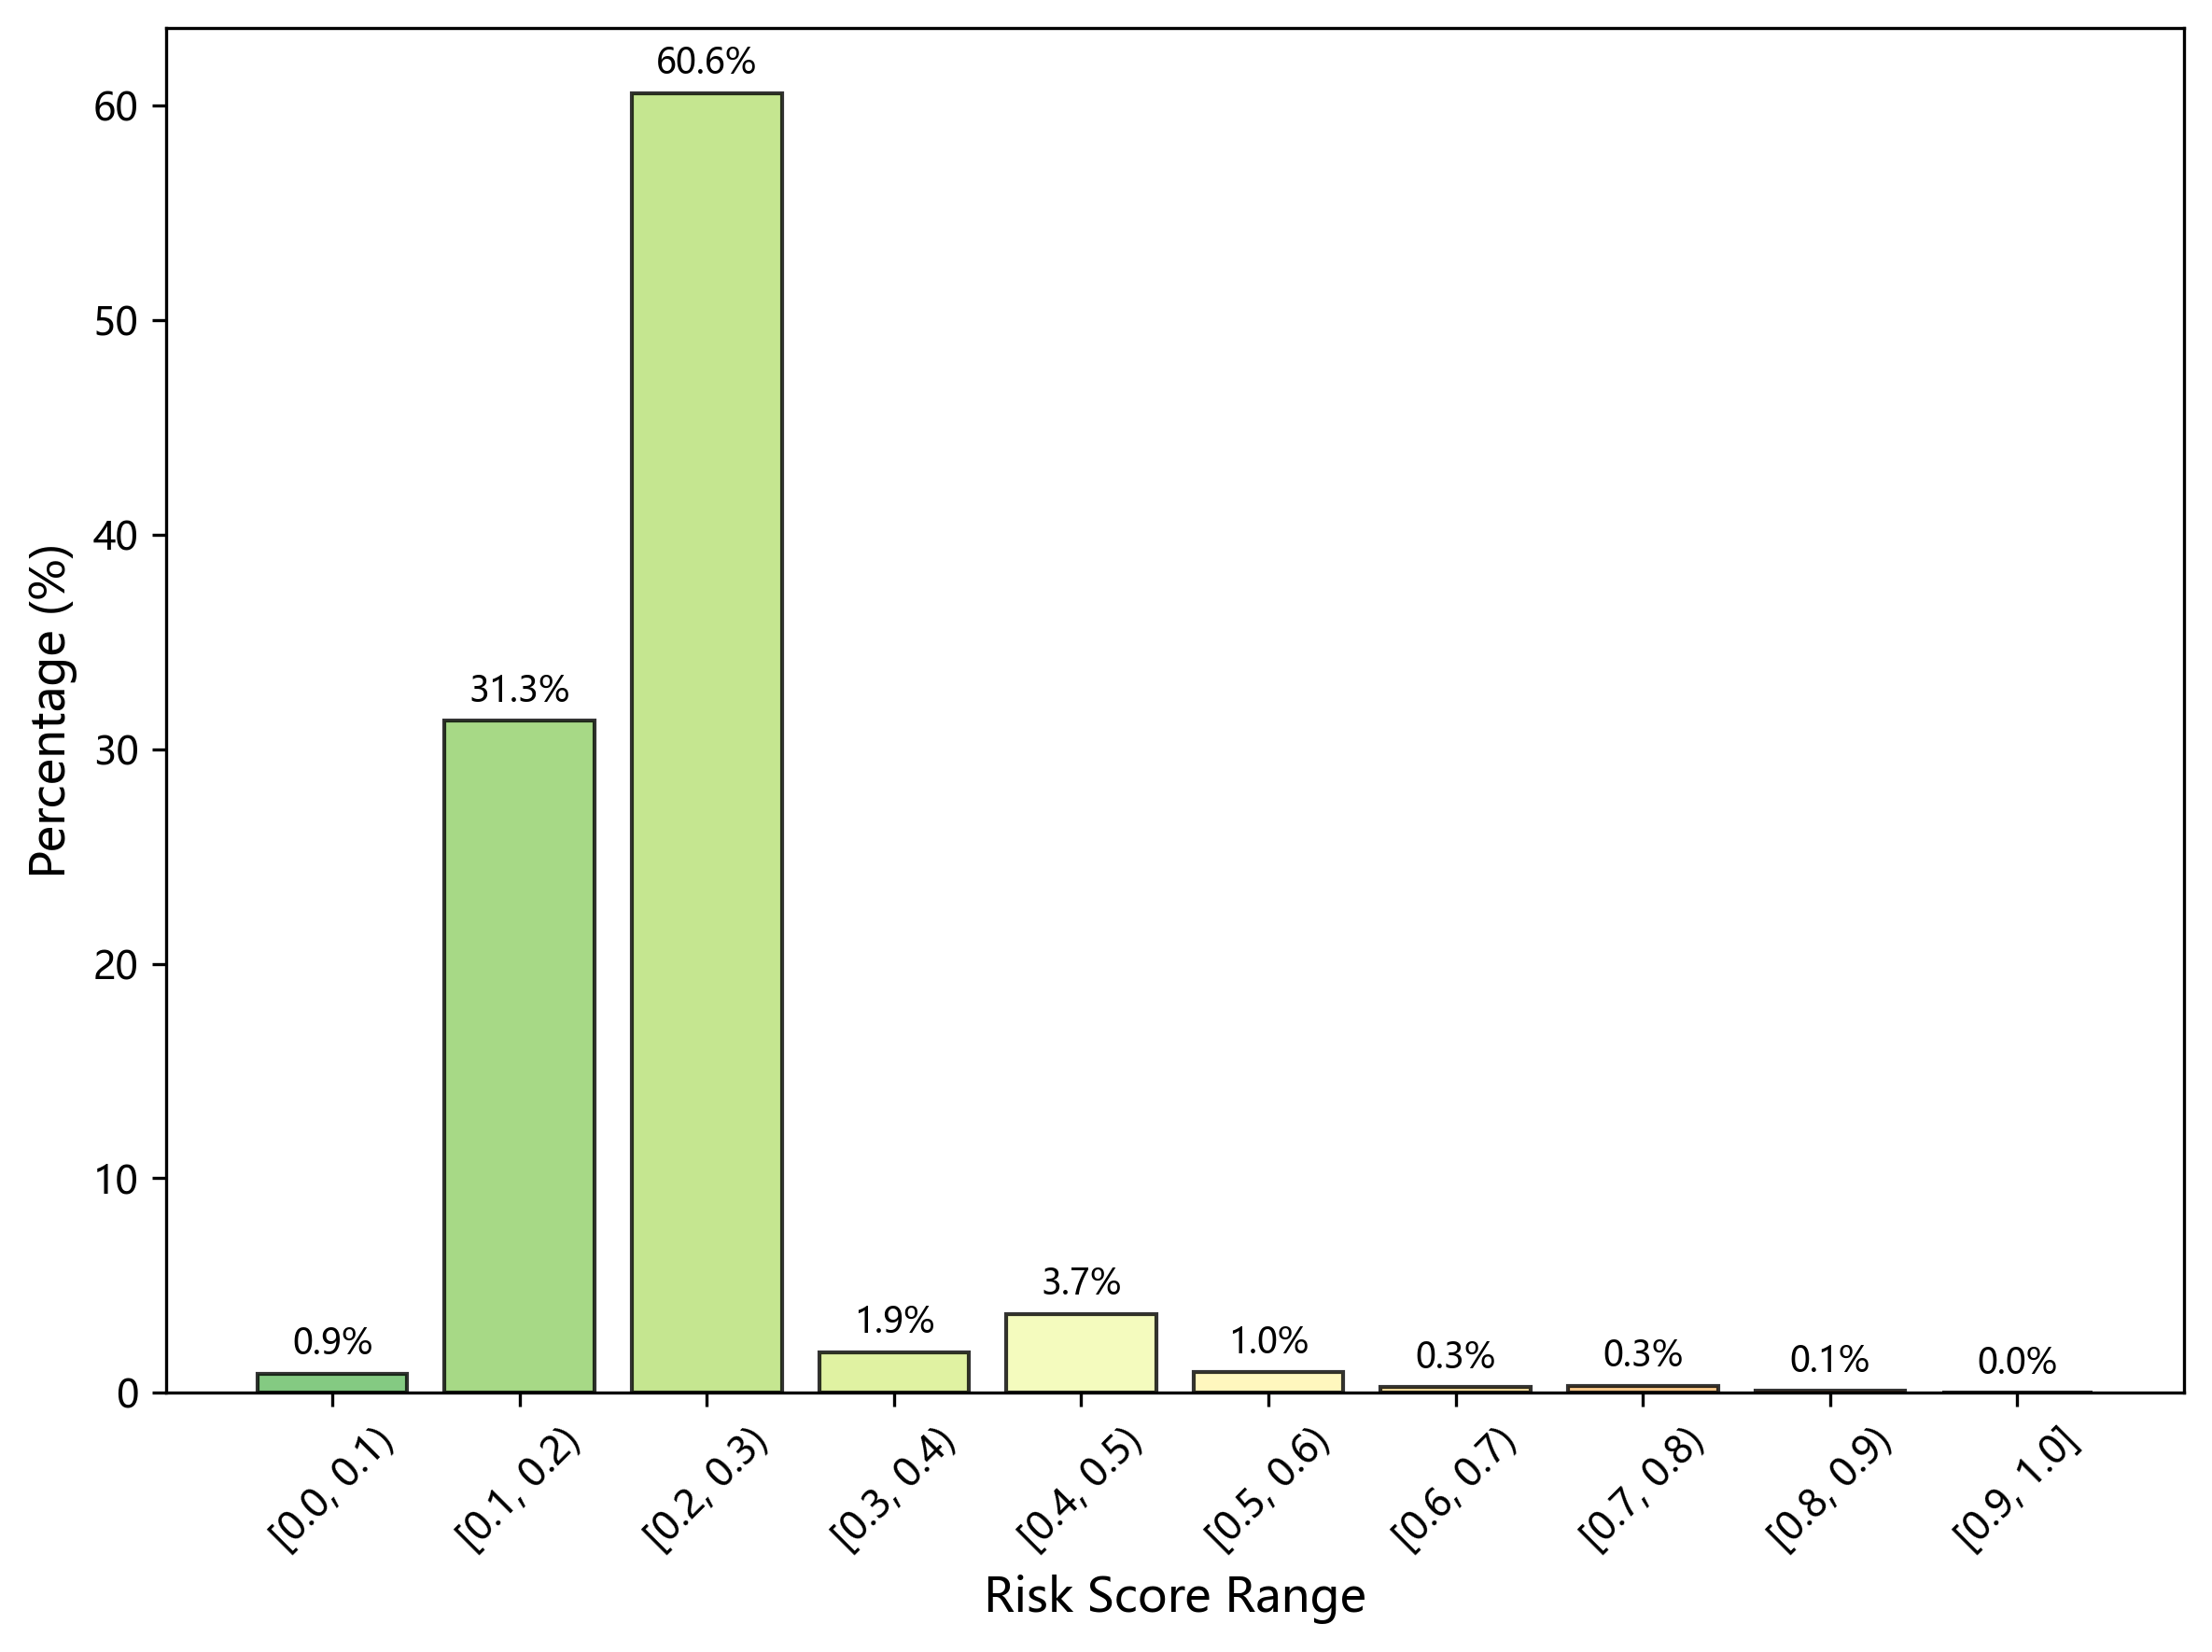

In [14]:
new = 1 # 是否为新运行程序？
if new:
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['savefig.bbox'] = 'tight'
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['xtick.color'] = 'black'
    plt.rcParams['ytick.color'] = 'black'

# ==================== 1. 定义分段区间 ====================
bins = np.arange(0, 1.1, 0.1)
labels = [f"[{bins[i]:.1f}, {bins[i+1]:.1f})" for i in range(len(bins)-2)]
labels.append("[0.9, 1.0]")

df['score_bin'] = pd.cut(df['norm_risk_score'], bins=bins, right=False, labels=labels)
mask = df['norm_risk_score'] == 1.0
df.loc[mask, 'score_bin'] = "[0.9, 1.0]"

# ==================== 2. 统计数量与比例 ====================
counts = df['score_bin'].value_counts().reindex(labels, fill_value=0)
ratios = counts / counts.sum()

print("=" * 60)
print("归一化风险得分分段统计")
print("=" * 60)
print(f"{'区间':<12} {'样本数':>10} {'比例':>10}")
print("-" * 40)
for label in labels:
    cnt = counts[label]
    pct = ratios[label]
    print(f"{label:<12} {cnt:>10,} {pct:>9.2%}")
print("-" * 40)
print(f"{'总计':<12} {counts.sum():>10,} {'100.00%':>10}")

# ==================== 3. 独立输出两张图片为PDF ====================

# 定义统一的图片尺寸（宽、高）
fig_width = 8   # 英寸
fig_height = 6  # 英寸

# 3.1 第一张图：直方图（计数）
fig1, ax1 = plt.subplots(figsize=(fig_width, fig_height))
bars = ax1.bar(labels, counts.values, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Risk Score Range', fontsize=12)
ax1.set_ylabel('Amount', fontsize=12)
# ax1.set_title('Number of Samples in Each Score Range', fontsize=14)
ax1.tick_params(axis='x', rotation=45)
ax1.ticklabel_format(axis='y', style='plain', useOffset=False)

# 添加数据标签
for bar, cnt in zip(bars, counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{cnt:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("risk_score_histogram.pdf", dpi=300, bbox_inches='tight')
plt.show()

# 3.2 第二张图：百分比柱状图
fig2, ax2 = plt.subplots(figsize=(fig_width, fig_height))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(labels)))
bars2 = ax2.bar(labels, ratios.values * 100, color=colors, edgecolor='black', alpha=0.8)
ax2.set_xlabel('Risk Score Range', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
# ax2.set_title('Percentage of Samples in Each Score Range', fontsize=14)
ax2.tick_params(axis='x', rotation=45)

# 添加百分比标签
for bar, pct in zip(bars2, ratios.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{pct:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("risk_score_percentage.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 保存统计结果

In [12]:
# # 可选：保存统计结果为 CSV
# stats_df = pd.DataFrame({'区间': labels, '样本数': counts.values, '比例': ratios.values})
# stats_df.to_csv('risk_score_distribution.csv', index=False, encoding='utf-8-sig')
# print("\n统计结果已保存至 'risk_score_distribution.csv'")